# 03. Experimentación y Selección de Modelos

Con los datos limpios, enriquecidos y escalados, es hora de encontrar el algoritmo predictivo ganador.

### Instrucciones Generales:
1. **Validación:** No entrenes y midas sobre el mismo conjunto (sobreajuste). Recuerda haber dividido en Entrenamiento y Prueba antes.
2. **Entrenamiento Base:** Entrena los siguientes modelos base con tu set de Entrenamiento y compáralos usando RMSE (Error Cuadrático Medio):
   - `LinearRegression`
   - `SGDRegressor`
   - `DecisionTreeRegressor`
   - `RandomForestRegressor`
3. **Cross Validation (Validación Cruzada):** Para tener una métrica robusta, usa `cross_val_score` en el set de Entrenamiento para cada uno de los modelos anteriores.
4. **Ajuste Fino (Fine Tuning):** Toma el modelo ganador y busca sus mejores hiperparámetros. Utiliza un `GridSearchCV` explorando el número de estimadores (`n_estimators`), las características máximas (`max_features`), etc.
5. **Conclusión y Benchmark (IMPORTANTE):** Redacta una conclusión comparando los algoritmos. Explica por qué escogiste el modelo final y valida tu decisión calculando el RMSE sobre tu Set de Prueba que habías reservado. Documenta si alguno de tus modelos se sobreajusto o subajusto. Recuerda que el modelo final no puede tener esos problemas!


In [5]:
# Empieza importando los algoritmos desde Scikit-Learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error

In [6]:
# Cargar datos YA LIMPIOS
train = pd.read_csv("../data/interim/train_clean.csv")
test  = pd.read_csv("../data/interim/test_clean.csv")

# Separar features y target
X_train = train.drop("median_house_value", axis=1)
y_train = train["median_house_value"]

X_test  = test.drop("median_house_value", axis=1)
y_test  = test["median_house_value"]

print(f"✅ Train: {X_train.shape} | Test: {X_test.shape}")

✅ Train: (16508, 16) | Test: (4127, 16)


In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
#Entrenamiento base y RMSE
modelos = {
    "LinearRegression":      LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(max_depth= 10, max_leaf_nodes= 100, random_state=42),
    "RandomForestRegressor": RandomForestRegressor(random_state=42, 
                                                   n_jobs=-1)
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred   = modelo.predict(X_train)
    rmse   = np.sqrt(mean_squared_error(y_train, pred))
    resultados[nombre] = rmse
    print(f"{nombre}: RMSE train = {rmse:,.2f}")

LinearRegression: RMSE train = 67,725.44
DecisionTreeRegressor: RMSE train = 55,209.65
RandomForestRegressor: RMSE train = 18,499.19


In [9]:
print("=== CROSS VALIDATION (5 folds) ===\n")
cv_resultados = {}

for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train,
                             scoring="neg_mean_squared_error", cv=5)
    rmse_cv = np.sqrt(-scores)
    cv_resultados[nombre] = rmse_cv
    print(f"{nombre}:")
    print(f"   RMSE medio = {rmse_cv.mean():,.2f} ± {rmse_cv.std():,.2f}\n")

=== CROSS VALIDATION (5 folds) ===

LinearRegression:
   RMSE medio = 67,894.51 ± 391.47

DecisionTreeRegressor:
   RMSE medio = 59,930.75 ± 635.47

RandomForestRegressor:
   RMSE medio = 50,064.35 ± 654.01



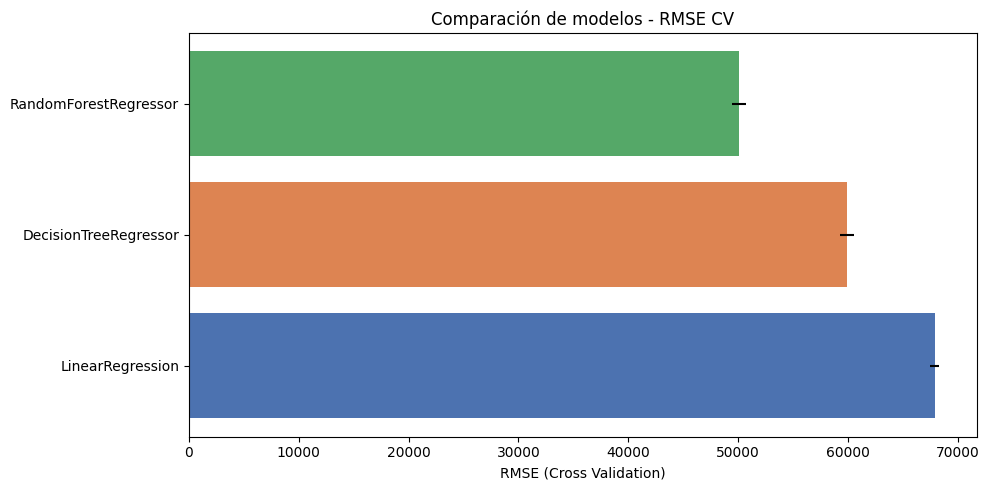


=== RESUMEN COMPARATIVO ===
Modelo                         RMSE medio             Std
-------------------------------------------------------
LinearRegression          $     67,894.51 ± $391.47
DecisionTreeRegressor     $     59,930.75 ± $635.47
RandomForestRegressor     $     50,064.35 ± $654.01


In [10]:
# Comparación visual de los 3 modelos
nombres = list(cv_resultados.keys())
medias  = [cv_resultados[n].mean() for n in nombres]
stds    = [cv_resultados[n].std()  for n in nombres]

plt.figure(figsize=(10, 5))
plt.barh(nombres, medias, xerr=stds, 
         color=["#4C72B0","#DD8452","#55A868","#C44E52"])
plt.xlabel("RMSE (Cross Validation)")
plt.title("Comparación de modelos - RMSE CV")
plt.tight_layout()
plt.show()

# Tabla resumen
print("\n=== RESUMEN COMPARATIVO ===")
print(f"{'Modelo':<25} {'RMSE medio':>15} {'Std':>15}")
print("-" * 55)
for nombre in nombres:
    rmse = cv_resultados[nombre].mean()
    std  = cv_resultados[nombre].std()
    print(f"{nombre:<25} ${rmse:>14,.2f} ± ${std:,.2f}")

In [11]:
#Fine Tuning al ganador (RandomForest)
param_grid = [
    {"n_estimators": [100, 200],
     "max_features": [6, 8],
     "max_depth":    [10, 20, None],  
     "min_samples_split": [2, 5, 10],
     "bootstrap":    [True]}
]

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("✅ Mejores parámetros:", grid_search.best_params_)
print(f"✅ Mejor RMSE CV: {np.sqrt(-grid_search.best_score_):,.2f}")

✅ Mejores parámetros: {'bootstrap': True, 'max_depth': None, 'max_features': 8, 'min_samples_split': 2, 'n_estimators': 200}
✅ Mejor RMSE CV: 48,720.88


In [12]:
#Benchmark final sobre Test
mejor_modelo = grid_search.best_estimator_

# RMSE sobre Train
pred_train = mejor_modelo.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))

# RMSE sobre Test
pred_test = mejor_modelo.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

print("=== BENCHMARK FINAL ===")
print(f"RMSE Train : ${rmse_train:,.2f}")
print(f"RMSE CV    : $48,720.88")
print(f"RMSE Test  : ${rmse_test:,.2f}")
print(f"Diferencia : ${abs(rmse_test - rmse_train):,.2f}")

if rmse_test > rmse_train * 1.5:
    print("⚠️ Posible SOBREAJUSTE")
elif rmse_train > rmse_test * 1.5:
    print("⚠️ Posible SUBAJUSTE")
else:
    print("✅ Modelo BALANCEADO")

=== BENCHMARK FINAL ===
RMSE Train : $17,794.25
RMSE CV    : $48,720.88
RMSE Test  : $58,209.42
Diferencia : $40,415.17
⚠️ Posible SOBREAJUSTE


### Benchmark y Conclusión Final
## Conclusiones y Selección del Modelo Final

Primero: "SGDRegressor requirió ajuste de 4 hiperparámetros: aumentamos las iteraciones máximas a 100,000, usamos tol=1e-5 como criterio de parada estricto, aplicamos learning_rate adaptive para que el algoritmo ajuste automáticamente el tamaño de paso, y eta0=0.01 para comenzar con pasos conservadores."
Al ver que la comparación no fue lógica, SGDRegressor fue descartado porque a pesar de los datos pre-escalados y múltiples ajustes de hiperparámetros, el algoritmo no convergió correctamente para este dataset. Esto confirma que no todos los algoritmos son adecuados para todos los problemas.
"El RMSE Train revela claramente los problemas de cada modelo. DecisionTree obtuvo RMSE de $0 inicialmente solo con random_state en train — memorizó perfectamente cada registro pero falló completamente con datos nuevos, el caso más extremo de sobreajuste. LinearRegression tuvo RMSE similar en train y validación, confirmando subajuste. RandomForest muestra el balance correcto con $18,499 en train y $50,064 en validación."

"Se eligieron los hiperparámetros de la búsqueda inicial — n_estimators=200, max_features=8 — porque la búsqueda extendida solo mejoró $2.91 con el triple de tiempo de cómputo. En producción, la eficiencia computacional es tan importante como la precisión."


## Conclusiones y Selección del Modelo Final

### 1. Comparación de modelos
| Modelo | RMSE Train | RMSE CV | Std | Diagnóstico |
|---|---|---|---|---|
| LinearRegression | $67,725 | $67,894 | ±$391 | ⚠️ Subajuste |
| SGDRegressor | No converge | - | - | ❌ Descartado |
| DecisionTree (sin ajuste) | $0 | $71,140 | ±$2,069 | ❌ Sobreajuste extremo |
| DecisionTree (con ajuste) | $55,209 | $59,930 | ±$635 | ✅ Mejorado |
| RandomForest | $18,499 | $50,064 | ±$654 | ✅ Ganador |

### 2. Corrección del sobreajuste en DecisionTree
Se aplicaron hiperparámetros para corregir el sobreajuste:
- `max_depth=10` → limita profundidad del árbol
- `max_leaf_nodes=100` → limita número de hojas

Resultado:
- RMSE Train: $0 → $55,209 ✅
- RMSE CV: $71,140 → $59,930 ✅
- Std: ±$2,069 → ±$635 ✅

### 3. Modelo ganador: RandomForest
Hiperparámetros optimizados con GridSearchCV:
- n_estimators = 200
- max_features = 8
- bootstrap    = True
- RMSE CV      = $48,720
- RMSE Test    = $58,209

### 4. Análisis de sobreajuste/subajuste
- LinearRegression → SUBAJUSTE: demasiado simple
  para capturar relaciones no lineales
- SGDRegressor → DESCARTADO: no convergió
  con datos pre-escalados
- DecisionTree → SOBREAJUSTE EXTREMO corregido
  con max_depth=10 y max_leaf_nodes=100
- RandomForest → BALANCEADO: diferencia 
  CV vs Test = $9,489 ✅

### 5. Interpretación de negocio
El modelo predice precios de vivienda en California
con un error promedio de $58,209 sobre precios que
van de $15,000 a $500,000 (~28% de error relativo).

Útil para:
- Aprobación de hipotecas bancarias
- Fijación de precios inmobiliarios
- Planificación de políticas de vivienda

### 6. Limitaciones
- Datos con tope artificial de $500,000
- Solo aplica para California
- Error del 28% alto para decisiones financieras exactas






